The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


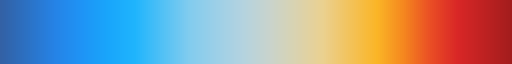

In [36]:
%load_ext autoreload
%autoreload 2
import os
os.chdir("/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/Scenicplus/Oligo")
import scanpy as sc
import pandas as pd
import numpy as np
import seaborn as sns
from scipy import sparse
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.colors import LinearSegmentedColormap

# 渐变 colormap
exp_colors = ["#EDEDED", "#FFF7F3","#F7FCF0","#E0F3DB","#CCEBC5","#7BCCC4","#4EB3D3","#2B8CBE","#0868AC","#084081"]
exp_cmap = LinearSegmentedColormap.from_list("my_cmap", exp_colors, N=256)
exp_cmap

acc_colors = ["#EDEDED", "#fddfdb","#edb8b0","#e69191","#c25759"]
acc_cmap = LinearSegmentedColormap.from_list("my_cmap", acc_colors, N=256)
acc_cmap

RNA_colors = ["#352A86", "#343296", "#343AA7", "#2646BB", "#1156D0", "#0366DE", "#0A76D8", "#1286D2", "#1C99C0", "#27ADAC", "#46B897", "#78BB7E", "#A9BD67", "#CCBC57", "#EFBA47", "#F7C438", "#F6D12B", "#F6DF1F", "#F7EC16", "#F8FA0D"]
RNA_cmap = LinearSegmentedColormap.from_list("my_cmap", RNA_colors, N=256)
RNA_cmap

ATAC_colors = ["#3361A5", "#2C72C5", "#2683E6", "#1F94F6", "#19A6FB", "#20B5FD", "#51C1F6", "#81CCEF", "#9CD0E8", "#B4D3E0", "#C9D4CD", "#DAD3B0", "#EBD190", "#F3C35B", "#FBB627", "#F5871F", "#EA4E25", "#D92727", "#BE2222", "#A31D1D"]
ATAC_cmap = LinearSegmentedColormap.from_list("my_cmap", ATAC_colors, N=256)
ATAC_cmap

In [ ]:
"#352A86", "#343296", "#343AA7", 
"#2646BB", "#1156D0", "#0366DE", 
"#0A76D8", "#1286D2", "#1C99C0", 
"#27ADAC", "#46B897", "#78BB7E", 
"#A9BD67", "#CCBC57", "#EFBA47", 
"#F7C438", "#F6D12B", "#F6DF1F", 
"#F7EC16", "#F8FA0D"

In [3]:
import mudata
scplus_mdata = mudata.read("outs/scplusmdata.h5mu")
scplus_mdata

/cluster2/huanglab/jiamao/conda/envs/scenicplus/lib/python3.11/site-packages/anndata/_core/anndata.py:522: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
/cluster2/huanglab/jiamao/conda/envs/scenicplus/lib/python3.11/site-packages/anndata/_core/anndata.py:522: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
/cluster2/huanglab/jiamao/conda/envs/scenicplus/lib/python3.11/site-packages/anndata/_core/anndata.py:522: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
/cluster2/huanglab/jiamao/conda/envs/scenicplus/lib/python3.11/site-packages/anndata/_core/anndata.py:522: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
/cluster2/huanglab/jiamao/conda/envs/scenicplus/lib/python3.11/site-packages/anndata/_core/anndata.py:522: FutureWarning: The dtype argument is deprecated and will be removed i

MuData object with n_obs × n_vars = 9282 × 178079
  uns:	'direct_e_regulon_metadata', 'extended_e_regulon_metadata'
  6 modalities
    scRNA_counts:	9282 x 36601
      obs:	'sample2', 'barcode2', 'celltype'
      var:	'gene_ids', 'feature_types'
    scATAC_counts:	9282 x 141240
      obs:	'cisTopic_nr_frag', 'cisTopic_log_nr_frag', 'cisTopic_nr_acc', 'cisTopic_log_nr_acc', 'sample_id', 'sample2', 'barcode2', 'celltype'
      var:	'Chromosome', 'Start', 'End', 'Width', 'cisTopic_nr_frag', 'cisTopic_log_nr_frag', 'cisTopic_nr_acc', 'cisTopic_log_nr_acc'
    direct_gene_based_AUC:	9282 x 70
    direct_region_based_AUC:	9282 x 70
    extended_gene_based_AUC:	9282 x 49
    extended_region_based_AUC:	9282 x 49

# Plot RNA value on trajectory

In [ ]:
adata_rna = scplus_mdata.mod['scRNA_counts']
adata_rna.obs['group'] = adata_rna.obs['sample2'].astype(str) + '_' + adata_rna.obs['barcode2'].astype(str)
adata_rna

AnnData object with n_obs × n_vars = 9282 × 36601
    obs: 'sample2', 'barcode2', 'celltype', 'group'
    var: 'gene_ids', 'feature_types'
    uns: 'log1p'
    layers: 'counts'

In [ ]:
adata_rna.obs

,sample2,barcode2,celltype,group
TCGTTTCCAACTCGCG-1-7___cisTopic,GW20,TCGTTTCCAACTCGCG-1,MOL,GW20_TCGTTTCCAACTCGCG-1
CCTCCTGAGTTAGTTG-1-7___cisTopic,GW20,CCTCCTGAGTTAGTTG-1,OPC,GW20_CCTCCTGAGTTAGTTG-1
CGTCCTAGTAACCTAG-1-1___cisTopic,GW12,CGTCCTAGTAACCTAG-1,OPC,GW12_CGTCCTAGTAACCTAG-1
CATCATGCAGGCCATT-1-6___cisTopic,GW17,CATCATGCAGGCCATT-1,OPC,GW17_CATCATGCAGGCCATT-1
GAAAGCCAGCTATTGA-1-5___cisTopic,GW16,GAAAGCCAGCTATTGA-1,MFOL,GW16_GAAAGCCAGCTATTGA-1
...,...,...,...,...
GTTAACCAGTAAGAAC-1-5___cisTopic,GW16,GTTAACCAGTAAGAAC-1,OPC,GW16_GTTAACCAGTAAGAAC-1
TACTTCGTCTGTTCAT-1-5___cisTopic,GW16,TACTTCGTCTGTTCAT-1,NPC,GW16_TACTTCGTCTGTTCAT-1
CACAAGCGTTGAGCCG-1-5___cisTopic,GW16,CACAAGCGTTGAGCCG-1,COP,GW16_CACAAGCGTTGAGCCG-1
TTGCGTCTCCATAAGC-1-5___cisTopic,GW16,TTGCGTCTCCATAAGC-1,OPC,GW16_TTGCGTCTCCATAAGC-1


In [ ]:
adata_rna.layers['counts'] = adata_rna.X.copy()
sc.pp.normalize_total(adata_rna)
sc.pp.log1p(adata_rna)

In [16]:
barcode_groups = pd.read_csv('/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/scPrinter/Oligo/seq2print/barcode_groups_latent_time_based.csv', sep=',', header=0)[['barcode','group']]
barcode_groups

,barcode,group
0,GW9_CTTTGAGCATTGACAT-1,COP_pbulk_1
1,GW16_ACCTACCTCCCGTTGT-1,COP_pbulk_1
2,GW20_ATATGGTGTTTGAGGC-1,COP_pbulk_1
3,GW16_CAAGGTTTCCCTGACT-1,COP_pbulk_1
4,GW16_ATGGCTAGTAACGAGG-1,COP_pbulk_1
...,...,...
48219,GW20_GGACATAAGTGCTGTG-1,dIPC_pbulk_6
48220,GW12_GGAACCACAGCAAGAT-1,dIPC_pbulk_6
48221,GW17_TGTGCGGGTTACAACG-1,dIPC_pbulk_6
48222,GW17_GGAACAATCAAGTGTC-1,dIPC_pbulk_6


In [17]:
selected_groups=['NPC_pbulk_6', 'NPC_pbulk_5', 'NPC_pbulk_1', 'NPC_pbulk_2', 'NPC_pbulk_3', 'NPC_pbulk_4', 
                 'dIPC_pbulk_1', 'dIPC_pbulk_2', 'dIPC_pbulk_3', 'dIPC_pbulk_4', 'dIPC_pbulk_5', 'dIPC_pbulk_6',
                 'OPC_pbulk_1', 'OPC_pbulk_2', 'OPC_pbulk_3', 'OPC_pbulk_4', 'OPC_pbulk_5', 'OPC_pbulk_6', 'OPC_pbulk_7', 'OPC_pbulk_8', 'OPC_pbulk_9', 'OPC_pbulk_10', 'OPC_pbulk_11', 'OPC_pbulk_12', 'OPC_pbulk_13', 'OPC_pbulk_14', 'OPC_pbulk_15', 'OPC_pbulk_16', 'OPC_pbulk_17', 'OPC_pbulk_18', 'OPC_pbulk_19','OPC_pbulk_20', 'OPC_pbulk_21', 
                 'COP_pbulk_1', 'COP_pbulk_2', 'COP_pbulk_3', 'COP_pbulk_4', 'COP_pbulk_5', 'COP_pbulk_6', 'COP_pbulk_7', 'COP_pbulk_8', 'COP_pbulk_9', 'COP_pbulk_10', 'COP_pbulk_11', 'COP_pbulk_12', 'COP_pbulk_13',
                 'MFOL_pbulk_1', 'MFOL_pbulk_2', 'MFOL_pbulk_3', 'MFOL_pbulk_4', 'MFOL_pbulk_5', 'MFOL_pbulk_6', 'MFOL_pbulk_7', 'MFOL_pbulk_8', 'MFOL_pbulk_9',
                 'MOL_pbulk_1', 'MOL_pbulk_2', 'MOL_pbulk_3', 'MOL_pbulk_4', 'MOL_pbulk_5', 
                 ]

completed gene: OLIG2
completed gene: OLIG1
completed gene: KLF9
completed gene: NFIC
completed gene: RREB1


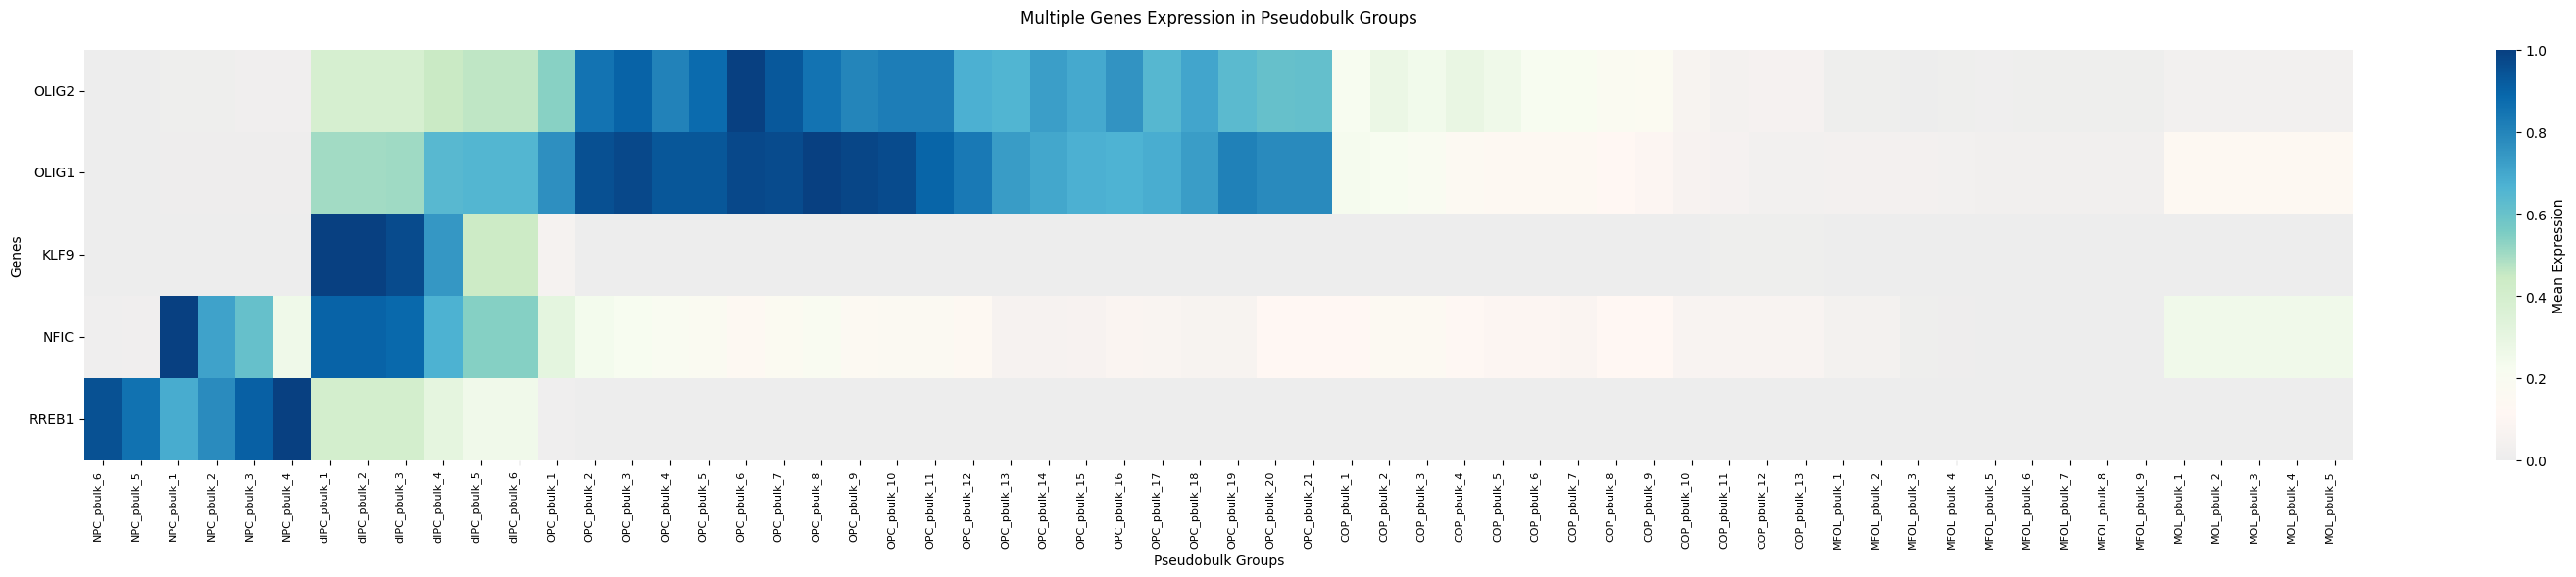

In [ ]:
# gene list
genes_to_plot = ['OLIG2', 'OLIG1', 'KLF9', 'NFIC', 'RREB1']
# matrix
expression_matrix = []
# calculate weighted expression for each gene
for gene in genes_to_plot:
    gene_idx = adata_rna.var_names.get_loc(gene)
    
    # store mean expression for each group
    gene_weighted_values = []
    
    for group in selected_groups:
        group_barcodes = barcode_groups[barcode_groups['group'] == group]['barcode'].tolist()
        cell_indices = adata_rna.obs['group'].isin(group_barcodes)
        
        if cell_indices.sum() > 0:
            # extract expression values
            if sparse.issparse(adata_rna.X):
                exp_values = adata_rna.X[cell_indices, gene_idx]
                if hasattr(exp_values, 'toarray'):
                    exp_values = exp_values.toarray().flatten()
            else:
                exp_values = adata_rna.X[cell_indices, gene_idx].flatten()
            
            # mean expression
            mean_expression = np.mean(exp_values)
            
            # expression frequency 
            expression_threshold = 1
            expressed_cells = (exp_values > expression_threshold).sum()
            expression_frequency = expressed_cells / cell_indices.sum()
            
            # weighted expression = mean expression * expression frequency
            weighted_expression = mean_expression * expression_frequency
            
            # record detailed information
            gene_weighted_values.append(weighted_expression)
        else:
            gene_weighted_values.append(np.nan)
        
    # add current gene result to matrix
    expression_matrix.append(gene_weighted_values)
    print(f"completed gene: {gene}")

# convert to numpy array
expression_matrix = np.array(expression_matrix)
expression_matrix_norm = np.zeros_like(expression_matrix)

for i in range(len(genes_to_plot)):
    row_values = expression_matrix[i, :]
    valid_mask = ~np.isnan(row_values)
    
    if valid_mask.any():
        valid_vals = row_values[valid_mask]
        min_val = np.min(valid_vals)
        max_val = np.max(valid_vals)
        
        if max_val > min_val:
            expression_matrix_norm[i, valid_mask] = (valid_vals - min_val) / (max_val - min_val)
        else:
            expression_matrix_norm[i, valid_mask] = 0.5
    else:
        expression_matrix_norm[i, :] = np.nan

# plot multiple genes heatmap
plt.figure(figsize=(max(len(selected_groups)/2, 10), max(len(genes_to_plot)/2, 6)))
heatmap = sns.heatmap(expression_matrix_norm,
                      cmap=exp_cmap,
                      yticklabels=genes_to_plot,  # y-axis labels are gene names
                      xticklabels=selected_groups,  # x-axis labels are group names
                      cbar_kws={'label': 'Mean Expression'},
                      linecolor=None,
                      square=False,
                      center=None,
                      annot_kws={'size': 6}) 

plt.xticks(rotation=90, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=10)
plt.title('Multiple Genes Expression in Pseudobulk Groups', fontsize=12, pad=20)
plt.xlabel('Pseudobulk Groups', fontsize=10)
plt.ylabel('Genes', fontsize=10)
plt.tight_layout()
plt.savefig('./plot/RNA_oligo1_2_level.pdf', format='pdf', dpi=300, bbox_inches='tight')
plt.show()

# Plot ATAC value on trajectory

In [95]:
adata_atac = scplus_mdata.mod['scATAC_counts']
adata_atac.obs['group'] = adata_atac.obs['sample2'].astype(str) + '_' + adata_atac.obs['barcode2'].astype(str)
adata_atac

AnnData object with n_obs × n_vars = 9282 × 141240
    obs: 'cisTopic_nr_frag', 'cisTopic_log_nr_frag', 'cisTopic_nr_acc', 'cisTopic_log_nr_acc', 'sample_id', 'sample2', 'barcode2', 'celltype', 'group'
    var: 'Chromosome', 'Start', 'End', 'Width', 'cisTopic_nr_frag', 'cisTopic_log_nr_frag', 'cisTopic_nr_acc', 'cisTopic_log_nr_acc'

In [99]:
adata_atac.obs

,cisTopic_nr_frag,cisTopic_log_nr_frag,cisTopic_nr_acc,cisTopic_log_nr_acc,sample_id,sample2,barcode2,celltype,group
TCGTTTCCAACTCGCG-1-7___cisTopic,3143,3.497344,1864,3.270446,cisTopic,GW20,TCGTTTCCAACTCGCG-1,MOL,GW20_TCGTTTCCAACTCGCG-1
CCTCCTGAGTTAGTTG-1-7___cisTopic,8423,3.925467,4802,3.681422,cisTopic,GW20,CCTCCTGAGTTAGTTG-1,OPC,GW20_CCTCCTGAGTTAGTTG-1
CGTCCTAGTAACCTAG-1-1___cisTopic,2279,3.357744,1264,3.101747,cisTopic,GW12,CGTCCTAGTAACCTAG-1,OPC,GW12_CGTCCTAGTAACCTAG-1
CATCATGCAGGCCATT-1-6___cisTopic,3443,3.536937,1980,3.296665,cisTopic,GW17,CATCATGCAGGCCATT-1,OPC,GW17_CATCATGCAGGCCATT-1
GAAAGCCAGCTATTGA-1-5___cisTopic,5813,3.764400,3374,3.528145,cisTopic,GW16,GAAAGCCAGCTATTGA-1,MFOL,GW16_GAAAGCCAGCTATTGA-1
...,...,...,...,...,...,...,...,...,...
GTTAACCAGTAAGAAC-1-5___cisTopic,6306,3.799754,3705,3.568788,cisTopic,GW16,GTTAACCAGTAAGAAC-1,OPC,GW16_GTTAACCAGTAAGAAC-1
TACTTCGTCTGTTCAT-1-5___cisTopic,8682,3.938620,4891,3.689398,cisTopic,GW16,TACTTCGTCTGTTCAT-1,NPC,GW16_TACTTCGTCTGTTCAT-1
CACAAGCGTTGAGCCG-1-5___cisTopic,4281,3.631545,2560,3.408240,cisTopic,GW16,CACAAGCGTTGAGCCG-1,COP,GW16_CACAAGCGTTGAGCCG-1
TTGCGTCTCCATAAGC-1-5___cisTopic,1302,3.114611,788,2.896526,cisTopic,GW16,TTGCGTCTCCATAAGC-1,OPC,GW16_TTGCGTCTCCATAAGC-1


In [98]:
adata_atac.var

,Chromosome,Start,End,Width,cisTopic_nr_frag,cisTopic_log_nr_frag,cisTopic_nr_acc,cisTopic_log_nr_acc
RegionIDs,,,,,,,,
chr1:817092-817593,chr1,817092,817593,501,50,1.698970,30,1.477121
chr1:827302-827803,chr1,827302,827803,501,1228,3.089198,706,2.848805
chr1:858597-859098,chr1,858597,859098,501,89,1.949390,53,1.724276
chr1:869671-870172,chr1,869671,870172,501,533,2.726727,287,2.457882
chr1:904519-905020,chr1,904519,905020,501,1049,3.020775,582,2.764923
...,...,...,...,...,...,...,...,...
chrY:19578483-19578984,chrY,19578483,19578984,501,271,2.432969,160,2.204120
chrY:19744468-19744969,chrY,19744468,19744969,501,250,2.397940,162,2.209515
chrY:19892009-19892510,chrY,19892009,19892510,501,133,2.123852,74,1.869232


In [ ]:
# 1. 解析目标区域
target_chr, target_pos = 'chr21:33115188-33115988'.split(':')
target_start, target_end = map(int, target_pos.split('-'))

# 2. 直接筛选
# 条件1: 相同染色体
chr_mask = adata_atac.var['Chromosome'] == target_chr
# 条件2: 区域有重叠 (结束位置 >= 目标起始位置 AND 起始位置 <= 目标结束位置)
overlap_mask = (adata_atac.var['End'] >= target_start) & (adata_atac.var['Start'] <= target_end)

# 3. 组合条件
overlap_peaks = adata_atac.var[chr_mask & overlap_mask]

# 4. 显示结果
print(f"与 chr21:33115188-33115988 有交集的peaks数量: {len(overlap_peaks)}")
overlap_peaks

与 chr21:33115188-33115988 有交集的peaks数量: 3


,Chromosome,Start,End,Width,cisTopic_nr_frag,cisTopic_log_nr_frag,cisTopic_nr_acc,cisTopic_log_nr_acc
RegionIDs,,,,,,,,
chr21:33115805-33116306,chr21,33115805,33116306,501,2169,3.336260,1221,3.086716
chr21:33117365-33117866,chr21,33117365,33117866,501,2580,3.411620,1383,3.140822
chr21:33116626-33117127,chr21,33116626,33117127,501,2016,3.304491,1160,3.064458


In [ ]:
region = 'chr21:33115805-33116306'

In [ ]:
# adata_atac.layers['counts'] = adata_atac.X.copy()
# sc.pp.normalize_total(adata_atac)
# sc.pp.log1p(adata_atac)

In [102]:
barcode_groups = pd.read_csv('/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/scPrinter/Oligo/seq2print/barcode_groups_latent_time_based.csv', sep=',', header=0)[['barcode','group']]
barcode_groups

,barcode,group
0,GW9_CTTTGAGCATTGACAT-1,COP_pbulk_1
1,GW16_ACCTACCTCCCGTTGT-1,COP_pbulk_1
2,GW20_ATATGGTGTTTGAGGC-1,COP_pbulk_1
3,GW16_CAAGGTTTCCCTGACT-1,COP_pbulk_1
4,GW16_ATGGCTAGTAACGAGG-1,COP_pbulk_1
...,...,...
48219,GW20_GGACATAAGTGCTGTG-1,dIPC_pbulk_6
48220,GW12_GGAACCACAGCAAGAT-1,dIPC_pbulk_6
48221,GW17_TGTGCGGGTTACAACG-1,dIPC_pbulk_6
48222,GW17_GGAACAATCAAGTGTC-1,dIPC_pbulk_6


In [103]:
selected_groups=['NPC_pbulk_6', 'NPC_pbulk_5', 'NPC_pbulk_1', 'NPC_pbulk_2', 'NPC_pbulk_3', 'NPC_pbulk_4', 
                 'dIPC_pbulk_1', 'dIPC_pbulk_2', 'dIPC_pbulk_3', 'dIPC_pbulk_4', 'dIPC_pbulk_5', 'dIPC_pbulk_6',
                 'OPC_pbulk_1', 'OPC_pbulk_2', 'OPC_pbulk_3', 'OPC_pbulk_4', 'OPC_pbulk_5', 'OPC_pbulk_6', 'OPC_pbulk_7', 'OPC_pbulk_8', 'OPC_pbulk_9', 'OPC_pbulk_10', 'OPC_pbulk_11', 'OPC_pbulk_12', 'OPC_pbulk_13', 'OPC_pbulk_14', 'OPC_pbulk_15', 'OPC_pbulk_16', 'OPC_pbulk_17', 'OPC_pbulk_18', 'OPC_pbulk_19','OPC_pbulk_20', 'OPC_pbulk_21', 
                 'COP_pbulk_1', 'COP_pbulk_2', 'COP_pbulk_3', 'COP_pbulk_4', 'COP_pbulk_5', 'COP_pbulk_6', 'COP_pbulk_7', 'COP_pbulk_8', 'COP_pbulk_9', 'COP_pbulk_10', 'COP_pbulk_11', 'COP_pbulk_12', 'COP_pbulk_13',
                 'MFOL_pbulk_1', 'MFOL_pbulk_2', 'MFOL_pbulk_3', 'MFOL_pbulk_4', 'MFOL_pbulk_5', 'MFOL_pbulk_6', 'MFOL_pbulk_7', 'MFOL_pbulk_8', 'MFOL_pbulk_9',
                 'MOL_pbulk_1', 'MOL_pbulk_2', 'MOL_pbulk_3', 'MOL_pbulk_4', 'MOL_pbulk_5', 
                 ]

completed region: chr21:33115488-33115988 -> chr21:33115805-33116306


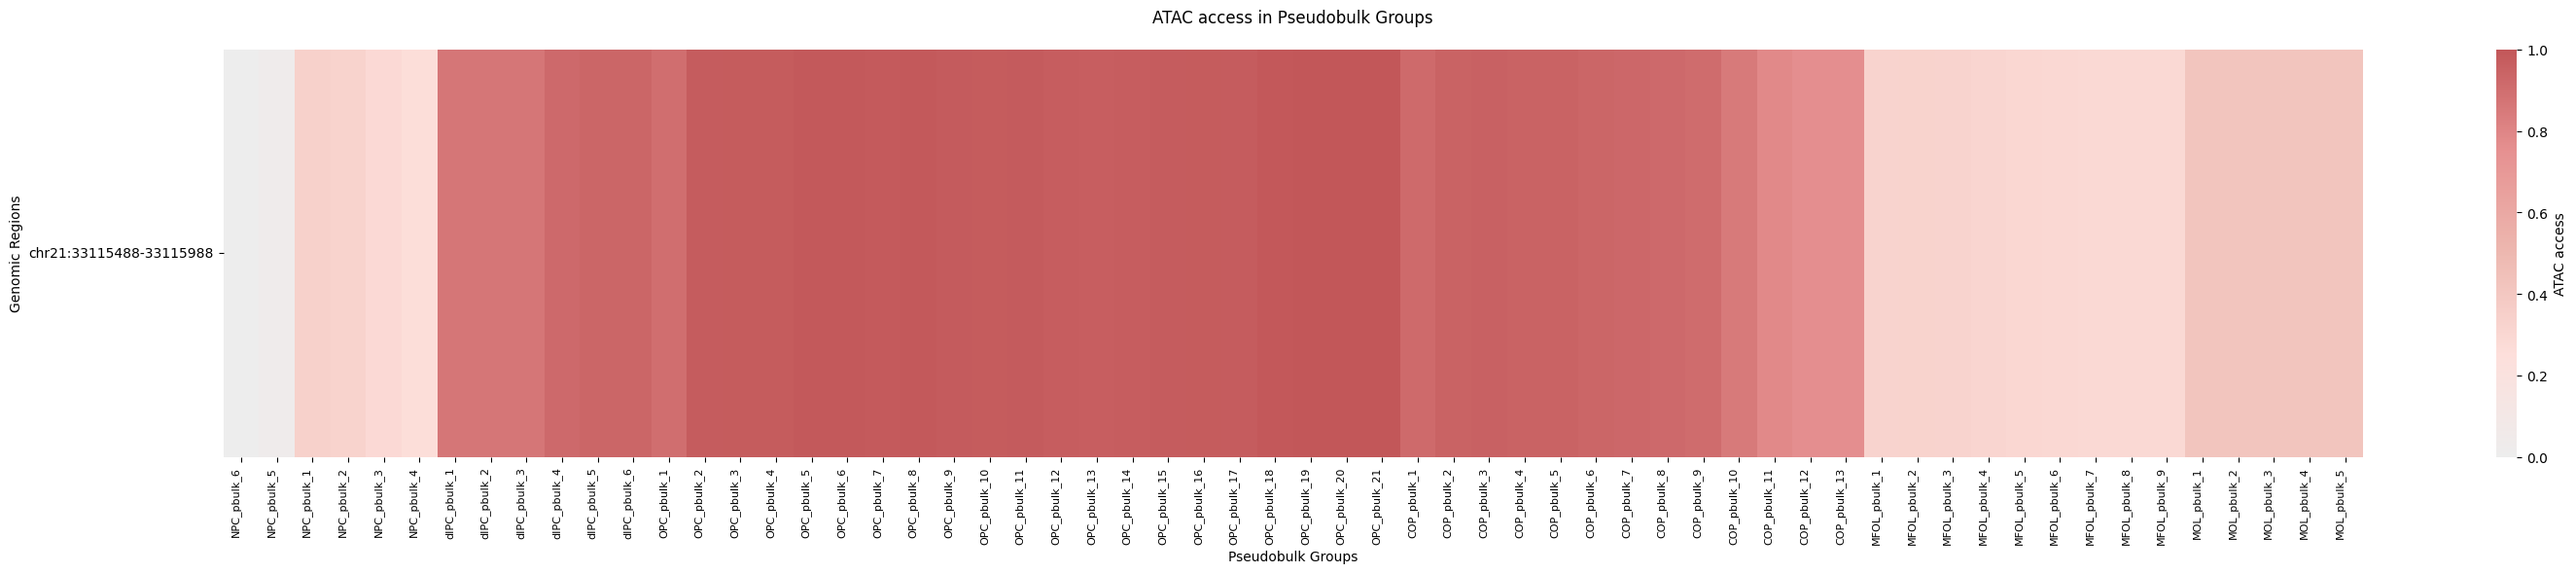

In [136]:
# region list
regions_to_plot = ['chr21:33115488-33115988']
# matrix
access_matrix = []
# calculate weighted access for each region
for region in regions_to_plot:
    target_chr, target_pos = region.split(':')
    target_start, target_end = map(int, target_pos.split('-'))
    
    # find peak
    peak_mask = (adata_atac.var['Chromosome'] == target_chr) & \
                (adata_atac.var['End'] >= target_start) & \
                (adata_atac.var['Start'] <= target_end)
    
    if peak_mask.sum() > 0:
        # use first overlapping peak
        peak_name = adata_atac.var_names[peak_mask][0]
        peak_idx = adata_atac.var_names.get_loc(peak_name)
        
        region_weighted_values = []
        
        for group in selected_groups:
            group_barcodes = barcode_groups[barcode_groups['group'] == group]['barcode'].tolist()
            cell_indices = adata_atac.obs['group'].isin(group_barcodes)
            
            if cell_indices.sum() > 0:
                if sparse.issparse(adata_atac.X):
                    access_values = adata_atac.X[cell_indices, peak_idx]
                    if hasattr(access_values, 'toarray'):
                        access_values = access_values.toarray().flatten()
                else:
                    access_values = adata_atac.X[cell_indices, peak_idx].flatten()
                
                # mean access
                mean_access = np.mean(access_values)
                
                # access frequency
                access_threshold = 0
                open_cells = (access_values > access_threshold).sum()
                access_frequency = open_cells / cell_indices.sum()
                
                # weighted access = mean access * access frequency
                weighted_access = mean_access * access_frequency
                
                region_weighted_values.append(weighted_access)
            else:
                region_weighted_values.append(np.nan)
        
        access_matrix.append(region_weighted_values)
        print(f"completed region: {region} -> {peak_name}")
    else:
        access_matrix.append([np.nan] * len(selected_groups))
        print(f"no peak found for region: {region}")

# convert to numpy array
access_matrix = np.array(access_matrix)
access_matrix_norm = np.zeros_like(access_matrix)

for i in range(len(regions_to_plot)):
    row_values = access_matrix[i, :]
    valid_mask = ~np.isnan(row_values)
    
    if valid_mask.any():
        valid_vals = row_values[valid_mask]
        min_val = np.min(valid_vals)
        max_val = np.max(valid_vals)
        
        if max_val > min_val:
            access_matrix_norm[i, valid_mask] = (valid_vals - min_val) / (max_val - min_val)
        else:
            access_matrix_norm[i, valid_mask] = 0.5
    else:
        access_matrix_norm[i, :] = np.nan

# plot multiple regions heatmap
plt.figure(figsize=(max(len(selected_groups)/2, 10), max(len(regions_to_plot)/2, 6)))
heatmap = sns.heatmap(access_matrix_norm,
                      cmap=acc_cmap,
                      yticklabels=regions_to_plot,
                      xticklabels=selected_groups,
                      cbar_kws={'label': 'ATAC access'},
                      linecolor=None,
                      square=False,
                      center=None,
                      annot_kws={'size': 6})

plt.xticks(rotation=90, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=10)
plt.title('ATAC access in Pseudobulk Groups', fontsize=12, pad=20)
plt.xlabel('Pseudobulk Groups', fontsize=10)
plt.ylabel('Genomic Regions', fontsize=10)
plt.tight_layout()
plt.savefig('./plot/ATAC_oligo_1_2_signal.pdf', format='pdf', dpi=300, bbox_inches='tight')
plt.show()

# Plot Gene-Peak links on trajectory

In [4]:
import mudata
scplus_mdata = mudata.read("outs/scplusmdata.h5mu")
scplus_mdata

/cluster2/huanglab/jiamao/conda/envs/scenicplus/lib/python3.11/site-packages/anndata/_core/anndata.py:522: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
/cluster2/huanglab/jiamao/conda/envs/scenicplus/lib/python3.11/site-packages/anndata/_core/anndata.py:522: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
/cluster2/huanglab/jiamao/conda/envs/scenicplus/lib/python3.11/site-packages/anndata/_core/anndata.py:522: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
/cluster2/huanglab/jiamao/conda/envs/scenicplus/lib/python3.11/site-packages/anndata/_core/anndata.py:522: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
/cluster2/huanglab/jiamao/conda/envs/scenicplus/lib/python3.11/site-packages/anndata/_core/anndata.py:522: FutureWarning: The dtype argument is deprecated and will be removed i

MuData object with n_obs × n_vars = 9282 × 178079
  uns:	'direct_e_regulon_metadata', 'extended_e_regulon_metadata'
  6 modalities
    scRNA_counts:	9282 x 36601
      obs:	'sample2', 'barcode2', 'celltype'
      var:	'gene_ids', 'feature_types'
    scATAC_counts:	9282 x 141240
      obs:	'cisTopic_nr_frag', 'cisTopic_log_nr_frag', 'cisTopic_nr_acc', 'cisTopic_log_nr_acc', 'sample_id', 'sample2', 'barcode2', 'celltype'
      var:	'Chromosome', 'Start', 'End', 'Width', 'cisTopic_nr_frag', 'cisTopic_log_nr_frag', 'cisTopic_nr_acc', 'cisTopic_log_nr_acc'
    direct_gene_based_AUC:	9282 x 70
    direct_region_based_AUC:	9282 x 70
    extended_gene_based_AUC:	9282 x 49
    extended_region_based_AUC:	9282 x 49

In [9]:
adata_rna = scplus_mdata.mod['scRNA_counts']
adata_rna.obs['group'] = adata_rna.obs['sample2'].astype(str) + '_' + adata_rna.obs['barcode2'].astype(str)
adata_rna

AnnData object with n_obs × n_vars = 9282 × 36601
    obs: 'sample2', 'barcode2', 'celltype', 'group'
    var: 'gene_ids', 'feature_types'

In [8]:
adata_atac = scplus_mdata.mod['scATAC_counts']
adata_atac.obs['group'] = adata_atac.obs['sample2'].astype(str) + '_' + adata_atac.obs['barcode2'].astype(str)
adata_atac

AnnData object with n_obs × n_vars = 9282 × 141240
    obs: 'cisTopic_nr_frag', 'cisTopic_log_nr_frag', 'cisTopic_nr_acc', 'cisTopic_log_nr_acc', 'sample_id', 'sample2', 'barcode2', 'celltype', 'group'
    var: 'Chromosome', 'Start', 'End', 'Width', 'cisTopic_nr_frag', 'cisTopic_log_nr_frag', 'cisTopic_nr_acc', 'cisTopic_log_nr_acc'

In [21]:
adata_atac.obs

,cisTopic_nr_frag,cisTopic_log_nr_frag,cisTopic_nr_acc,cisTopic_log_nr_acc,sample_id,sample2,barcode2,celltype,group,pseudobulk
TCGTTTCCAACTCGCG-1-7___cisTopic,3143,3.497344,1864,3.270446,cisTopic,GW20,TCGTTTCCAACTCGCG-1,MOL,GW20_TCGTTTCCAACTCGCG-1,MOL_pbulk_5
CCTCCTGAGTTAGTTG-1-7___cisTopic,8423,3.925467,4802,3.681422,cisTopic,GW20,CCTCCTGAGTTAGTTG-1,OPC,GW20_CCTCCTGAGTTAGTTG-1,OPC_pbulk_21
CGTCCTAGTAACCTAG-1-1___cisTopic,2279,3.357744,1264,3.101747,cisTopic,GW12,CGTCCTAGTAACCTAG-1,OPC,GW12_CGTCCTAGTAACCTAG-1,OPC_pbulk_21
CATCATGCAGGCCATT-1-6___cisTopic,3443,3.536937,1980,3.296665,cisTopic,GW17,CATCATGCAGGCCATT-1,OPC,GW17_CATCATGCAGGCCATT-1,OPC_pbulk_15
GAAAGCCAGCTATTGA-1-5___cisTopic,5813,3.764400,3374,3.528145,cisTopic,GW16,GAAAGCCAGCTATTGA-1,MFOL,GW16_GAAAGCCAGCTATTGA-1,MFOL_pbulk_9
...,...,...,...,...,...,...,...,...,...,...
GTTAACCAGTAAGAAC-1-5___cisTopic,6306,3.799754,3705,3.568788,cisTopic,GW16,GTTAACCAGTAAGAAC-1,OPC,GW16_GTTAACCAGTAAGAAC-1,OPC_pbulk_9
TACTTCGTCTGTTCAT-1-5___cisTopic,8682,3.938620,4891,3.689398,cisTopic,GW16,TACTTCGTCTGTTCAT-1,NPC,GW16_TACTTCGTCTGTTCAT-1,NPC_pbulk_4
CACAAGCGTTGAGCCG-1-5___cisTopic,4281,3.631545,2560,3.408240,cisTopic,GW16,CACAAGCGTTGAGCCG-1,COP,GW16_CACAAGCGTTGAGCCG-1,COP_pbulk_7
TTGCGTCTCCATAAGC-1-5___cisTopic,1302,3.114611,788,2.896526,cisTopic,GW16,TTGCGTCTCCATAAGC-1,OPC,GW16_TTGCGTCTCCATAAGC-1,OPC_pbulk_1


In [6]:
import pandas as pd
import numpy as np
import ast 

region_to_gene = pd.read_csv("/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/Scenicplus/Oligo/outs/region_to_gene_adj.tsv",sep = '\t')
region_df = region_to_gene.copy()
# prepare the distance column
def parse_distance(x):
    if isinstance(x, str):
        try:
            return abs(ast.literal_eval(x)[0])
        except:
            return 999999999
    elif isinstance(x, list):
        return abs(x[0])
    return abs(x)

region_df['abs_distance'] = region_df['Distance'].apply(parse_distance)

# set the filtering threshold
# condition 1: must be positively correlated (Open chromatin -> Gene Expression)
# set a slightly higher threshold 0.03, filter out very weak correlations
cond_rho = region_df['rho'] > 0.03 

# condition 2: Importance must be high
# strategy: take the 50th percentile of Importance (keep top 50% strong connections)
importance_cutoff = region_df['importance'].quantile(0.5)
cond_imp = region_df['importance'] > importance_cutoff

# condition 3: distance should not be too far
cond_dist = region_df['abs_distance'] < 500000


# filtering
region_filtered = region_df[cond_rho & cond_imp & cond_dist].copy()
print(f"original number of connections: {len(region_df)}")
print(f"number of connections after filtering: {len(region_filtered)}")

# preview
region_filtered.head()

original number of connections: 422371
number of connections after filtering: 61474


,target,region,importance,rho,importance_x_rho,importance_x_abs_rho,Distance,abs_distance
14,A2ML1,chr12:8689692-8690193,0.084664,0.069975,0.005924,0.005924,[132679],132679
16,A2ML1,chr12:8687707-8688208,0.104774,0.066157,0.006932,0.006932,[134663],134663
17,A2ML1,chr12:8697641-8698142,0.052208,0.036050,0.001882,0.001882,[124729],124729
21,A2ML1,chr12:8914190-8914691,0.044473,0.036853,0.001639,0.001639,[-27439],27439
23,A2ML1,chr12:8698402-8698903,0.059290,0.042637,0.002528,0.002528,[123969],123969


In [7]:
barcode_groups = pd.read_csv('/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/scPrinter/Oligo/seq2print/barcode_groups_latent_time_based.csv', sep=',', header=0)[['barcode','group']]
barcode_groups

,barcode,group
0,GW9_CTTTGAGCATTGACAT-1,COP_pbulk_1
1,GW16_ACCTACCTCCCGTTGT-1,COP_pbulk_1
2,GW20_ATATGGTGTTTGAGGC-1,COP_pbulk_1
3,GW16_CAAGGTTTCCCTGACT-1,COP_pbulk_1
4,GW16_ATGGCTAGTAACGAGG-1,COP_pbulk_1
...,...,...
48219,GW20_GGACATAAGTGCTGTG-1,dIPC_pbulk_6
48220,GW12_GGAACCACAGCAAGAT-1,dIPC_pbulk_6
48221,GW17_TGTGCGGGTTACAACG-1,dIPC_pbulk_6
48222,GW17_GGAACAATCAAGTGTC-1,dIPC_pbulk_6


In [15]:
psudo_bulk_order=['NPC_pbulk_6', 'NPC_pbulk_5', 'NPC_pbulk_1', 'NPC_pbulk_2', 'NPC_pbulk_3', 'NPC_pbulk_4', 
                 'dIPC_pbulk_1', 'dIPC_pbulk_2', 'dIPC_pbulk_3', 'dIPC_pbulk_4', 'dIPC_pbulk_5', 'dIPC_pbulk_6',
                 'OPC_pbulk_1', 'OPC_pbulk_2', 'OPC_pbulk_3', 'OPC_pbulk_4', 'OPC_pbulk_5', 'OPC_pbulk_6', 'OPC_pbulk_7', 'OPC_pbulk_8', 'OPC_pbulk_9', 'OPC_pbulk_10', 'OPC_pbulk_11', 'OPC_pbulk_12', 'OPC_pbulk_13', 'OPC_pbulk_14', 'OPC_pbulk_15', 'OPC_pbulk_16', 'OPC_pbulk_17', 'OPC_pbulk_18', 'OPC_pbulk_19','OPC_pbulk_20', 'OPC_pbulk_21', 
                 'COP_pbulk_1', 'COP_pbulk_2', 'COP_pbulk_3', 'COP_pbulk_4', 'COP_pbulk_5', 'COP_pbulk_6', 'COP_pbulk_7', 'COP_pbulk_8', 'COP_pbulk_9', 'COP_pbulk_10', 'COP_pbulk_11', 'COP_pbulk_12', 'COP_pbulk_13',
                 'MFOL_pbulk_1', 'MFOL_pbulk_2', 'MFOL_pbulk_3', 'MFOL_pbulk_4', 'MFOL_pbulk_5', 'MFOL_pbulk_6', 'MFOL_pbulk_7', 'MFOL_pbulk_8', 'MFOL_pbulk_9',
                 'MOL_pbulk_1', 'MOL_pbulk_2', 'MOL_pbulk_3', 'MOL_pbulk_4', 'MOL_pbulk_5', 
                 ]

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import zscore
from scipy.ndimage import gaussian_filter1d


# Key = Group Name, Value = List of Barcodes
group_to_barcodes = barcode_groups.groupby('group')['barcode'].apply(list).to_dict()

# Pseudobulk 
def compute_pseudobulk(adata, group_dict, order_list, match_col='group'):
    """
    adata: scRNA or scATAC object
    group_dict: {group_name: [barcode1, barcode2, ...]}
    order_list: list of group names
    match_col: column name in adata.obs for matching barcodes
    """
    print(f"Start processing {len(order_list)} groups...")
    
    # set match_col as temporary index to accelerate .loc lookup, or use boolean mask directly
    available_barcodes = set(adata.obs[match_col])
    results = []
    valid_groups = []
    
    for group_name in order_list:
        # get the theoretically expected barcodes from the external dictionary
        target_barcodes = group_dict.get(group_name, [])
        
        # take intersection: only keep cells that actually exist in adata
        valid_cells = [b for b in target_barcodes if b in available_barcodes]
        
        if len(valid_cells) == 0:
            # if this group is not found in the current adata, skip or fill 0
            continue
            
        # extract cells & calculate mean
        subset_mask = adata.obs[match_col].isin(valid_cells)
        subset_X = adata[subset_mask].X
        
        # calculate mean & flatten
        mean_val = subset_X.mean(axis=0)
        mean_exp = np.ravel(mean_val) # compatible with sparse matrix
        
        results.append(mean_exp)
        valid_groups.append(group_name)
        
    # DataFrame
    pb_df = pd.DataFrame(results, index=valid_groups, columns=adata.var_names).T
    
    print(f"Computed {len(valid_groups)} groups out of {len(order_list)} requested.")
    return pb_df, valid_groups

# calculation
rna_pb, valid_groups_rna = compute_pseudobulk(adata_rna, group_to_barcodes, psudo_bulk_order, match_col='group')
atac_pb, valid_groups_atac = compute_pseudobulk(adata_atac, group_to_barcodes, psudo_bulk_order, match_col='group')
final_groups = sorted(list(set(valid_groups_rna).intersection(valid_groups_atac)), key=lambda x: psudo_bulk_order.index(x))

# slice to ensure alignment
rna_pb = rna_pb[final_groups]
atac_pb = atac_pb[final_groups]

# align Gene-Peak Links
valid_genes = set(rna_pb.index)
valid_peaks = set(atac_pb.index)

final_links = region_filtered[
    region_filtered['target'].isin(valid_genes) & 
    region_filtered['region'].isin(valid_peaks)
].copy()

print(f"Links valid for plotting: {len(final_links)}")

# Features x TimePoints
mat_rna_raw = rna_pb.loc[final_links['target']].values
mat_atac_raw = atac_pb.loc[final_links['region']].values

# Z-score (axis=1 across time)
mat_rna_z = np.nan_to_num(zscore(mat_rna_raw, axis=1))
mat_atac_z = np.nan_to_num(zscore(mat_atac_raw, axis=1))

# Sorting strategy: based on RNA expression peak time
peak_time_rna = np.argmax(mat_rna_z, axis=1)
sorted_indices = np.argsort(peak_time_rna)

# Sort
mat_rna_sorted = mat_rna_z[sorted_indices, :]
mat_atac_sorted = mat_atac_z[sorted_indices, :]

# Smooth
sigma_val = 2.0
mat_rna_plot = gaussian_filter1d(mat_rna_sorted, sigma=sigma_val, axis=1)
mat_atac_plot = gaussian_filter1d(mat_atac_sorted, sigma=sigma_val, axis=1)

Start processing 60 groups...
Computed 60 groups out of 60 requested.
Start processing 60 groups...
Computed 60 groups out of 60 requested.
Links valid for plotting: 61474


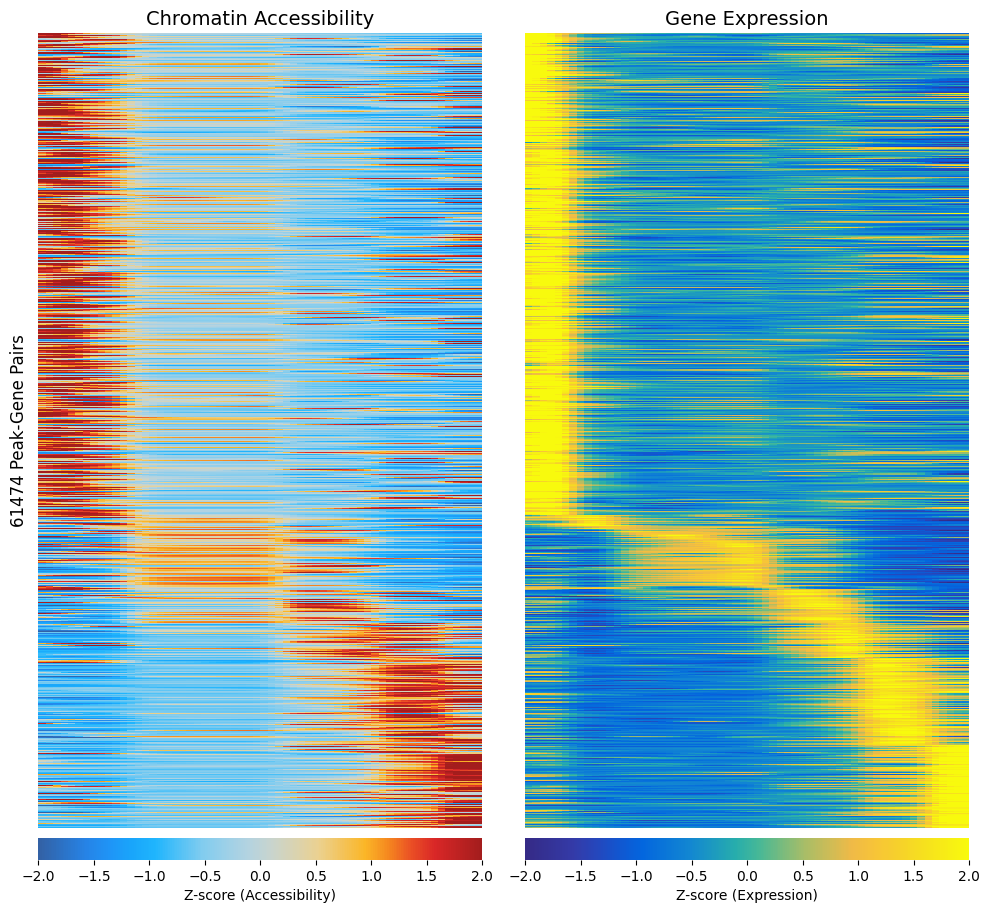

In [ ]:
# Plot
fig, axes = plt.subplots(1, 2, figsize=(10, 10), sharey=True)
vmin, vmax = -2.0, 2.0

# ATAC
sns.heatmap(mat_atac_plot, cmap=ATAC_cmap, vmin=vmin, vmax=vmax, 
            xticklabels=False, yticklabels=False, 
            cbar_kws={'label': 'Z-score (Accessibility)', 'location': 'bottom', 'pad':0.01},
            ax=axes[0],
            rasterized=True)
axes[0].set_title('Chromatin Accessibility', fontsize=14)
axes[0].set_xlabel('Pseudotime (Groups)', fontsize=12)
axes[0].set_ylabel(f'{len(final_links)} Peak-Gene Pairs', fontsize=12)

# RNA
sns.heatmap(mat_rna_plot, cmap=RNA_cmap, vmin=vmin, vmax=vmax, 
            xticklabels=False, yticklabels=False, 
            cbar_kws={'label': 'Z-score (Expression)', 'location': 'bottom', 'pad':0.01},
            ax=axes[1],
            rasterized=True)
axes[1].set_title('Gene Expression', fontsize=14)
axes[1].set_xlabel('Pseudotime (Groups)', fontsize=12)

plt.tight_layout()
plt.savefig("./plot/peak_gene_dynamics_oligo.pdf", dpi=300) 
plt.show()

Sorting based on ATAC Accessibility Peak Time...


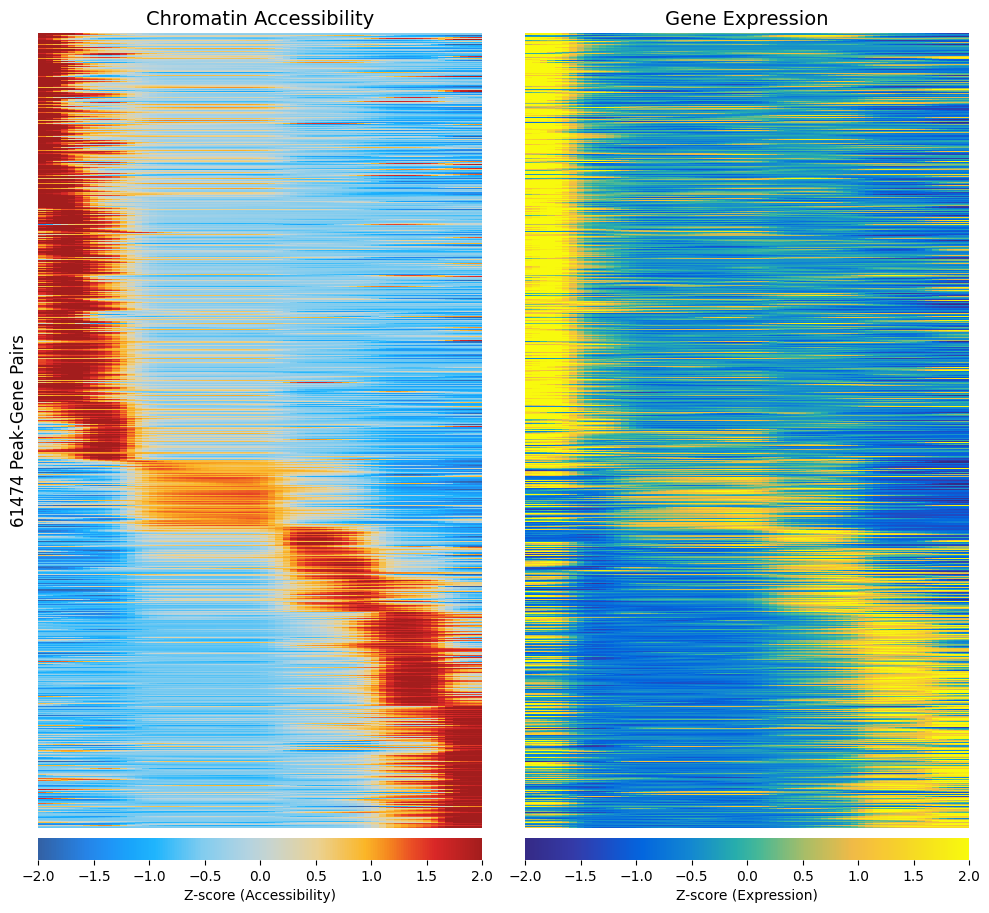

In [49]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import zscore
from scipy.ndimage import gaussian_filter1d

# (Rows = Pairs, Cols = Pseudotime Pseudobulk Groups)

# Z-score
# axis=1 across pseudotime
mat_rna_z = np.nan_to_num(zscore(mat_rna_raw, axis=1))
mat_atac_z = np.nan_to_num(zscore(mat_atac_raw, axis=1))

# Sorting logic: based on ATAC Accessibility Peak Time
print("Sorting based on ATAC Accessibility Peak Time...")

# find the bin index of the maximum ATAC accessibility
peak_time_atac = np.argmax(mat_atac_z, axis=1)

# get the sorting index
sorted_indices = np.argsort(peak_time_atac)

# apply sorting
# ATAC becomes a perfect waterfall
mat_atac_sorted = mat_atac_z[sorted_indices, :]
# RNA passively follows ATAC
mat_rna_sorted = mat_rna_z[sorted_indices, :]

# Smoothing & Plotting
sigma_val = 2.0
mat_rna_plot = gaussian_filter1d(mat_rna_sorted, sigma=sigma_val, axis=1)
mat_atac_plot = gaussian_filter1d(mat_atac_sorted, sigma=sigma_val, axis=1)

fig, axes = plt.subplots(1, 2, figsize=(10, 10), sharey=True)
vmin, vmax = -2.0, 2.0 

# --- Left: ATAC (now the baseline, should be a perfect diagonal) ---
sns.heatmap(mat_atac_plot, cmap=ATAC_cmap, vmin=vmin, vmax=vmax, 
            xticklabels=False, yticklabels=False, 
            cbar_kws={'label': 'Z-score (Accessibility)', 'location': 'bottom', 'pad':0.01},
            ax=axes[0],
            rasterized=True)
axes[0].set_title('Chromatin Accessibility', fontsize=14)
axes[0].set_xlabel('Pseudotime (Groups)', fontsize=12)
axes[0].set_ylabel(f'{len(mat_atac_sorted)} Peak-Gene Pairs', fontsize=12)

# --- Right: RNA (passively sorted, observe lag) ---
sns.heatmap(mat_rna_plot, cmap=RNA_cmap, vmin=vmin, vmax=vmax, 
            xticklabels=False, yticklabels=False, 
            cbar_kws={'label': 'Z-score (Expression)', 'location': 'bottom', 'pad':0.01},
            ax=axes[1],
            rasterized=True)
axes[1].set_title('Gene Expression', fontsize=14)
axes[1].set_xlabel('Pseudotime (Groups)', fontsize=12)

x_lim = axes[0].get_xlim()
y_lim = axes[0].get_ylim()

plt.tight_layout()
plt.savefig("./plot/peak_gene_dynamics_oligo_sorted_by_ATAC.pdf", dpi=300)
plt.show()

Total Links: 61474
Primed Links (ATAC peaks >= 3 bins earlier): 9704


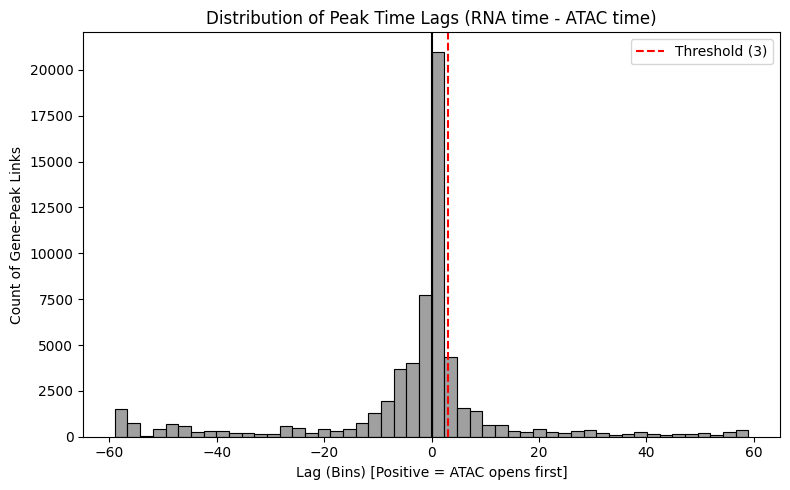

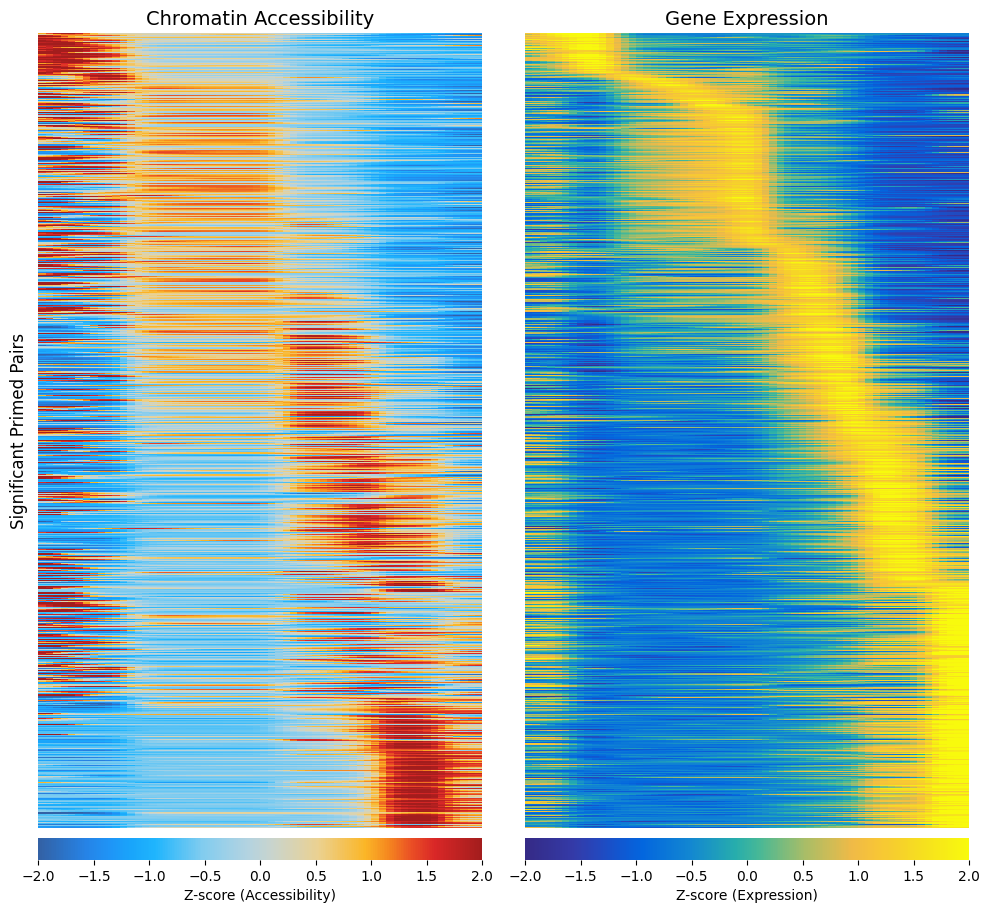

In [51]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


# Calculate Time Lag
# axis=1 returns the column index of the maximum value (0 ~ N_groups-1)
peak_time_rna = np.argmax(mat_rna_plot, axis=1)
peak_time_atac = np.argmax(mat_atac_plot, axis=1)

# Calculate Lag
time_lag = peak_time_rna - peak_time_atac

# Add to metadata for easy viewing
links_with_lag = final_links.copy()
links_with_lag['Peak_Time_RNA'] = peak_time_rna
links_with_lag['Peak_Time_ATAC'] = peak_time_atac
links_with_lag['Lag'] = time_lag
links_with_lag['Lag_Abs'] = np.abs(time_lag)

# Set Threshold
# For example: ATAC must be at least 5 bins earlier than RNA
LAG_THRESHOLD = 3 

# Filter Condition:
# 1. Lag > Threshold (ATAC opens earlier)
# 2. Exclude RNA peaks in the first few bins (avoid edge effects)
priming_mask = (time_lag >= LAG_THRESHOLD) & (peak_time_rna > 5)

priming_indices = np.where(priming_mask)[0]
primed_links = links_with_lag.iloc[priming_indices]

print(f"Total Links: {len(final_links)}")
print(f"Primed Links (ATAC peaks >= {LAG_THRESHOLD} bins earlier): {len(primed_links)}")

# Prepare Plotting Data (Only for Primed Links)

# Extract Subset
mat_rna_primed = mat_rna_plot[priming_indices, :]
mat_atac_primed = mat_atac_plot[priming_indices, :]

# Re-sort: still sort by RNA peak time
# Note: Here we use argsort on the subset
sort_idx_subset = np.argsort(peak_time_rna[priming_indices])

mat_rna_primed_sorted = mat_rna_primed[sort_idx_subset, :]
mat_atac_primed_sorted = mat_atac_primed[sort_idx_subset, :]

# Plot Distribution & Heatmap
plt.figure(figsize=(8, 5))
sns.histplot(time_lag, bins=50, kde=False, color='grey')
plt.axvline(LAG_THRESHOLD, color='red', linestyle='--', label=f'Threshold ({LAG_THRESHOLD})')
plt.axvline(0, color='black', linestyle='-')
plt.title("Distribution of Peak Time Lags (RNA time - ATAC time)")
plt.xlabel("Lag (Bins) [Positive = ATAC opens first]")
plt.ylabel("Count of Gene-Peak Links")
plt.legend()
plt.tight_layout()
plt.savefig("./plot/priming_lag_distribution.pdf", dpi=300)
plt.show()

# --- Primed Links ---
fig, axes = plt.subplots(1, 2, figsize=(10, 10), sharey=True)
vmin, vmax = -2.0, 2.0

# ATAC
sns.heatmap(mat_atac_primed_sorted, cmap=ATAC_cmap, vmin=vmin, vmax=vmax, 
            xticklabels=False, yticklabels=False, 
            cbar_kws={'label': 'Z-score (Accessibility)', 'location': 'bottom', 'pad':0.01},
            ax=axes[0],
            rasterized=True)
axes[0].set_title(f'Chromatin Accessibility', fontsize=14)
axes[0].set_xlabel('Pseudotime', fontsize=12)
axes[0].set_ylabel('Significant Primed Pairs', fontsize=12)

# RNA
sns.heatmap(mat_rna_primed_sorted, cmap=RNA_cmap, vmin=vmin, vmax=vmax, 
            xticklabels=False, yticklabels=False, 
            cbar_kws={'label': 'Z-score (Expression)', 'location': 'bottom', 'pad':0.01},
            ax=axes[1],
            rasterized=True)
axes[1].set_title('Gene Expression', fontsize=14)
axes[1].set_xlabel('Pseudotime', fontsize=12)

plt.tight_layout()
plt.savefig("./plot/peak_gene_dynamics_oligo_priming.pdf", dpi=300)
plt.show()

# Export Results
primed_links_sorted = primed_links.iloc[sort_idx_subset]
primed_links_sorted.to_csv("./outs/significant_primed_links.csv", index=False, sep='\t')

In [53]:
# Save All Links (sorted by RNA peak time + with Lag information)
# links_with_lag contains all links and the calculated Peak_Time and Lag

# use sorted_indices to sort the table with Lag information
all_links_sorted_with_lag = links_with_lag.iloc[sorted_indices]

# save the file
all_links_sorted_with_lag.to_csv("./outs/peak_gene_dynamics_oligo_all_sorted_with_lag.csv", index=False, sep='\t')